``Open in colab``

# Práctica 1: Estudio comparativo de algoritmos en un problema de k-armed bandit

**Descripción**: Description: El experimento compara el rendimiento de algoritmos epsilon-greedy en un problema de k-armed bandit. Se generan gráficas de recompensas promedio para cada algoritmo.

**Asignatura**: Extensiones de Machine Learning, 2025/2026

**Autores**: 
* Alberto Ortega Pastor
* Manuel Salas Díaz
* Lola Conde Herrera

**Máster de Inteligencia Artificial**

**Facultad de Informática**

-----

## Preparación del entorno

In [ ]:
!git clone https://github.com/Loicsav/SalasOrtegaConde1.git
%cd SalasOrtegaConde1

!pip install -r requirements.txt

In [74]:
import sys
import numpy as np
from typing import List

from algorithms import Algorithm, EpsilonGreedy
from arms import ArmNormal, Bandit, ArmBernoulli, ArmBinomial
from plotting import plot_average_rewards, plot_optimal_selections, plot_arm_statistics, plot_regret

In [75]:
seed = 42
np.random.seed(seed)

k = 10  # Número de brazos
steps = 1000  # Número de pasos que se ejecutarán cada algoritmo
runs = 500  # Número de ejecuciones

# Algoritmo  ε-greedy

## Experimentos

In [76]:
def run_experiment(bandit: Bandit, algorithms: List[Algorithm], steps: int, runs: int):

    # Recopilar estadísticas de brazos para cada algoritmo
    arm_stats = []
    for algo in algorithms:
        arm_data = [
            {
                'arm': i + 1,  # Número del brazo (1 al k)
                'counts': 0.0,  # Número de veces seleccionado
                'values': 0.0,  # Recompensa promedio estimada
            }
            for i in range(algo.k)
        ]
        arm_stats.append(arm_data)

    optimal_arm = bandit.optimal_arm  # Necesario para calcular el porcentaje de selecciones óptimas.

    rewards = np.zeros((len(algorithms), steps)) # Matriz para almacenar las recompensas promedio.

    optimal_selections = np.zeros((len(algorithms), steps))  # Matriz para almacenar el porcentaje de selecciones óptimas.

    regrets = np.zeros((len(algorithms), steps))  # Matriz para almacenar el regret acumulado.

    for run in range(runs):
        current_bandit = Bandit(arms=bandit.arms)

        for algo in algorithms:
            algo.reset() # Reiniciar los valores de los algoritmos.

        total_rewards_per_algo = np.zeros(len(algorithms)) # Acumulador de recompensas por algoritmo. Necesario para calcular el promedio.

        for step in range(steps):
            for idx, algo in enumerate(algorithms):
                chosen_arm = algo.select_arm() # Seleccionar un brazo según la política del algoritmo.
                reward = current_bandit.pull_arm(chosen_arm) # Obtener la recompensa del brazo seleccionado.
                algo.update(chosen_arm, reward) # Actualizar el valor estimado del brazo seleccionado.

                rewards[idx, step] += reward # Acumular la recompensa obtenida en la matriz rewards para el algoritmo idx en el paso step.
                total_rewards_per_algo[idx] += reward # Acumular la recompensa obtenida en total_rewards_per_algo para el algoritmo idx.

                regrets[idx, step] += (current_bandit.get_expected_value(optimal_arm) - reward) # Acumular el regret obtenido en la matriz regrets para el algoritmo idx en el paso step.

                if chosen_arm == optimal_arm:
                    optimal_selections[idx, step] += 1
        for arms_algo, algo in zip(arm_stats, algorithms):
            for arm_data in arms_algo:
                i = arm_data["arm"] -1
                arm_data["counts"] = arm_data["counts"] + algo.counts[i]
                arm_data["values"] = arm_data["values"] + float(algo.values[i])



    rewards /= runs
    regrets /= runs
    optimal_selections /= runs
    
    # Recopilar estadísticas de brazos para cada algoritmo
    for arms_algo, algo in zip(arm_stats, algorithms):
            for arm_data in arms_algo:
                i = arm_data["arm"] -1
                arm_data["values"] = arm_data["values"]/runs
                arm_data["counts"] = int(arm_data["counts"]/runs)

    return rewards, optimal_selections, arm_stats, regrets

## ``Experimento distribución Normal``

In [77]:
# Creación del bandit
bandit = Bandit(arms=ArmNormal.generate_arms(k)) # Generar un bandido con k brazos de distribución normal
print(bandit)

optimal_arm = bandit.optimal_arm
print(f"Optimal arm: {optimal_arm + 1} with expected reward={bandit.get_expected_value(optimal_arm)}")

# Definir los algoritmos a comparar. En este caso son 3 algoritmos epsilon-greedy con diferentes valores de epsilon.
algorithms = [EpsilonGreedy(k=k, epsilon=0), EpsilonGreedy(k=k, epsilon=0.01), EpsilonGreedy(k=k, epsilon=0.1)]

# Ejecutar el experimento y obtener las recompensas promedio, porcentaje de selecciones óptimas y estadísticas de brazos
rewards, optimal_selections, arm_stats, regrets = run_experiment(bandit, algorithms, steps, runs)

Bandit with 10 arms: ArmNormal(mu=1.52, sigma=1.0), ArmNormal(mu=2.4, sigma=1.0), ArmNormal(mu=1.19, sigma=1.0), ArmNormal(mu=4.37, sigma=1.0), ArmNormal(mu=6.39, sigma=1.0), ArmNormal(mu=7.59, sigma=1.0), ArmNormal(mu=8.8, sigma=1.0), ArmNormal(mu=9.56, sigma=1.0), ArmNormal(mu=6.41, sigma=1.0), ArmNormal(mu=7.37, sigma=1.0)
Optimal arm: 8 with expected reward=9.56


### Visualización

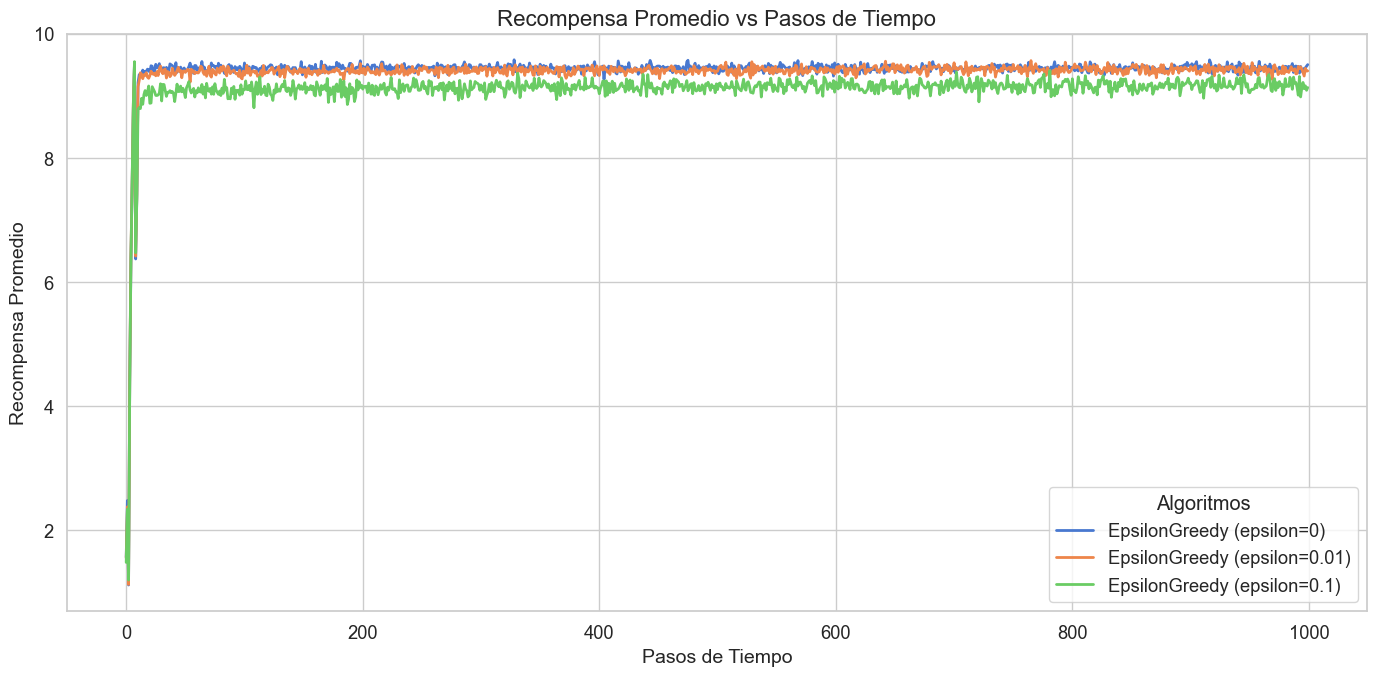

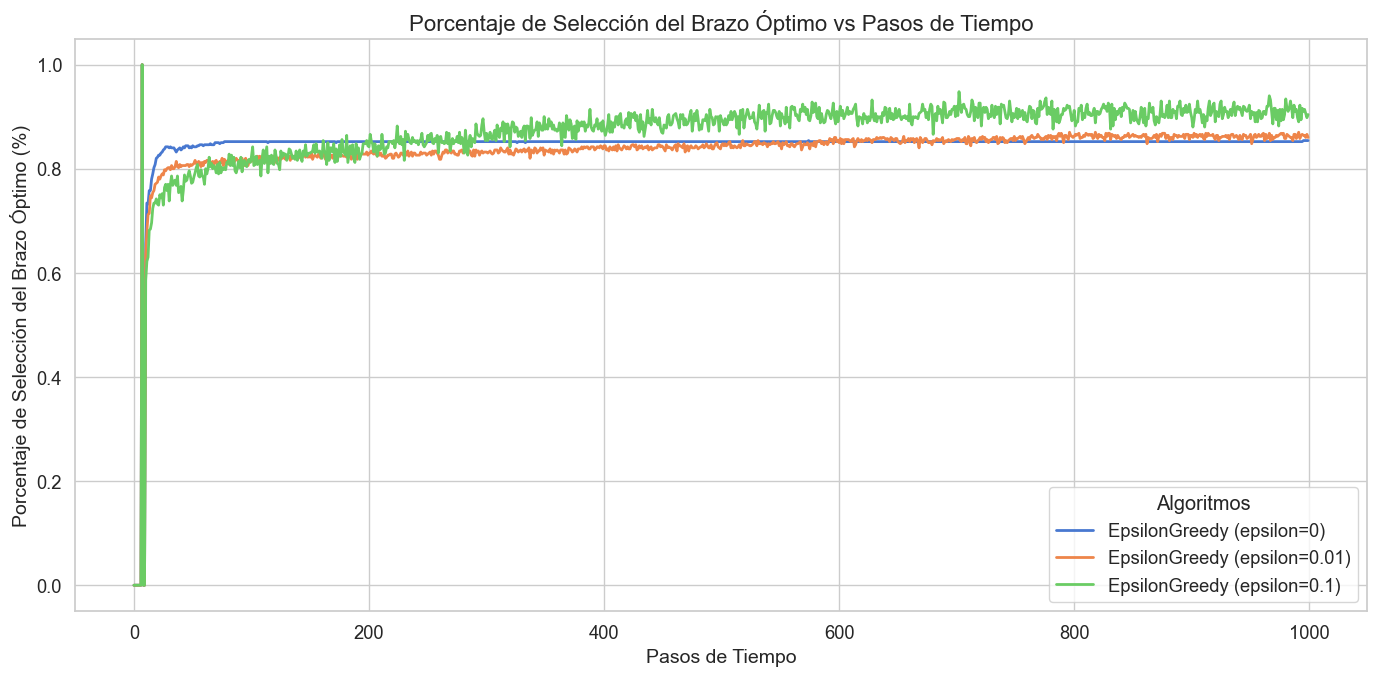


Estadísticas de brazos - EpsilonGreedy (epsilon=0)
Brazo 1: Recompensa Promedio = 1.5596, Selecciones = 1
Brazo 2: Recompensa Promedio = 2.4732, Selecciones = 1
Brazo 3: Recompensa Promedio = 1.1120, Selecciones = 1
Brazo 4: Recompensa Promedio = 4.4020, Selecciones = 1
Brazo 5: Recompensa Promedio = 6.3066, Selecciones = 1
Brazo 6: Recompensa Promedio = 7.4652, Selecciones = 1
Brazo 7: Recompensa Promedio = 8.4516, Selecciones = 146
Brazo 8: Recompensa Promedio = 9.3481, Selecciones = 843 (ÓPTIMO)
Brazo 9: Recompensa Promedio = 6.3638, Selecciones = 1
Brazo 10: Recompensa Promedio = 7.3404, Selecciones = 3


c:\Users\lolac\Documents\GitHub\SalasOrtegaConde1\plotting\plotting.py:136: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(x_labels, rotation=45, ha="right", fontsize=10)


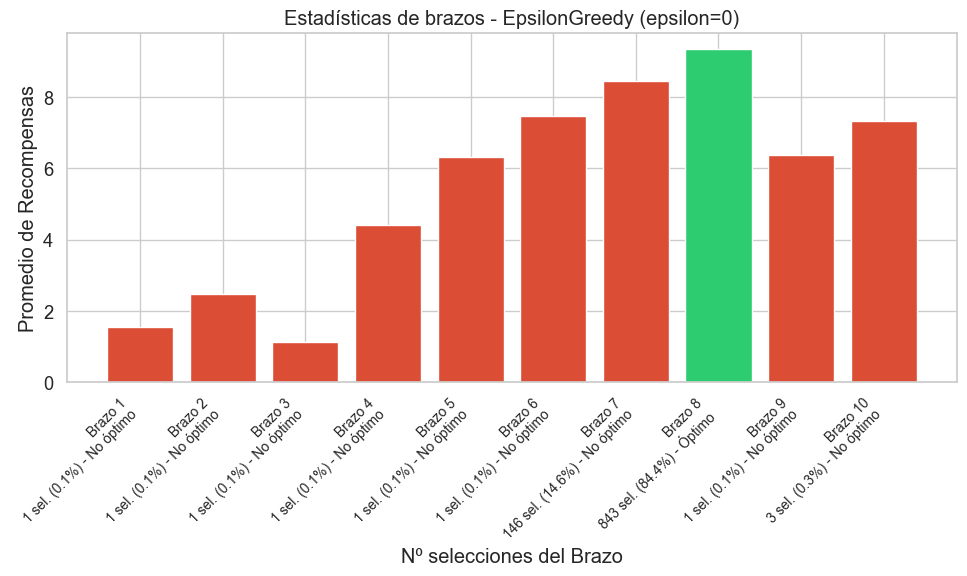


Estadísticas de brazos - EpsilonGreedy (epsilon=0.01)
Brazo 1: Recompensa Promedio = 1.5536, Selecciones = 1
Brazo 2: Recompensa Promedio = 2.3755, Selecciones = 1
Brazo 3: Recompensa Promedio = 1.1359, Selecciones = 1
Brazo 4: Recompensa Promedio = 4.4567, Selecciones = 1
Brazo 5: Recompensa Promedio = 6.4326, Selecciones = 2
Brazo 6: Recompensa Promedio = 7.5333, Selecciones = 2
Brazo 7: Recompensa Promedio = 8.6059, Selecciones = 149
Brazo 8: Recompensa Promedio = 9.3929, Selecciones = 834 (ÓPTIMO)
Brazo 9: Recompensa Promedio = 6.3954, Selecciones = 1
Brazo 10: Recompensa Promedio = 7.3732, Selecciones = 2


c:\Users\lolac\Documents\GitHub\SalasOrtegaConde1\plotting\plotting.py:136: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(x_labels, rotation=45, ha="right", fontsize=10)


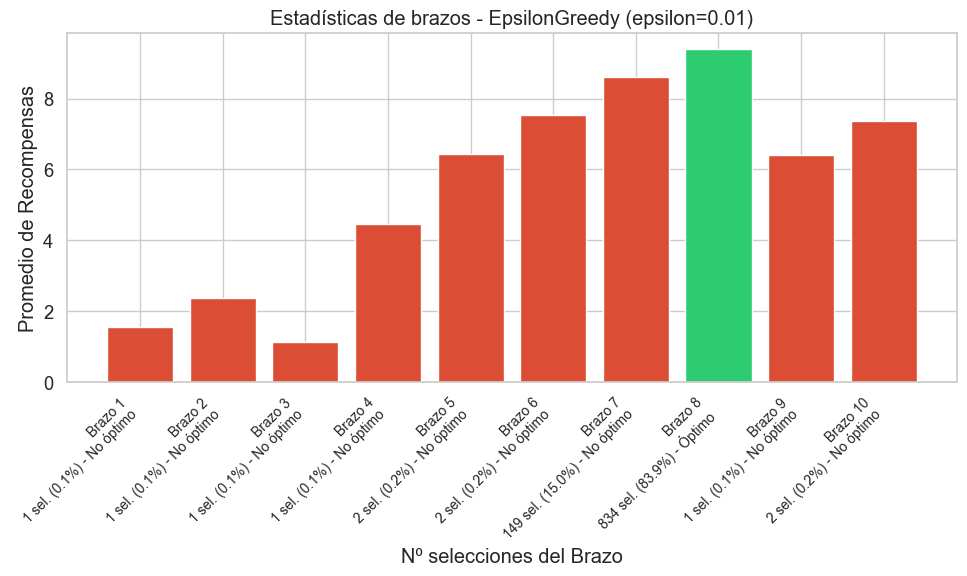

c:\Users\lolac\Documents\GitHub\SalasOrtegaConde1\plotting\plotting.py:136: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(x_labels, rotation=45, ha="right", fontsize=10)



Estadísticas de brazos - EpsilonGreedy (epsilon=0.1)
Brazo 1: Recompensa Promedio = 1.5179, Selecciones = 10
Brazo 2: Recompensa Promedio = 2.3921, Selecciones = 10
Brazo 3: Recompensa Promedio = 1.2018, Selecciones = 10
Brazo 4: Recompensa Promedio = 4.3687, Selecciones = 10
Brazo 5: Recompensa Promedio = 6.3924, Selecciones = 10
Brazo 6: Recompensa Promedio = 7.5922, Selecciones = 11
Brazo 7: Recompensa Promedio = 8.7567, Selecciones = 44
Brazo 8: Recompensa Promedio = 9.5571, Selecciones = 868 (ÓPTIMO)
Brazo 9: Recompensa Promedio = 6.4237, Selecciones = 10
Brazo 10: Recompensa Promedio = 7.3821, Selecciones = 11


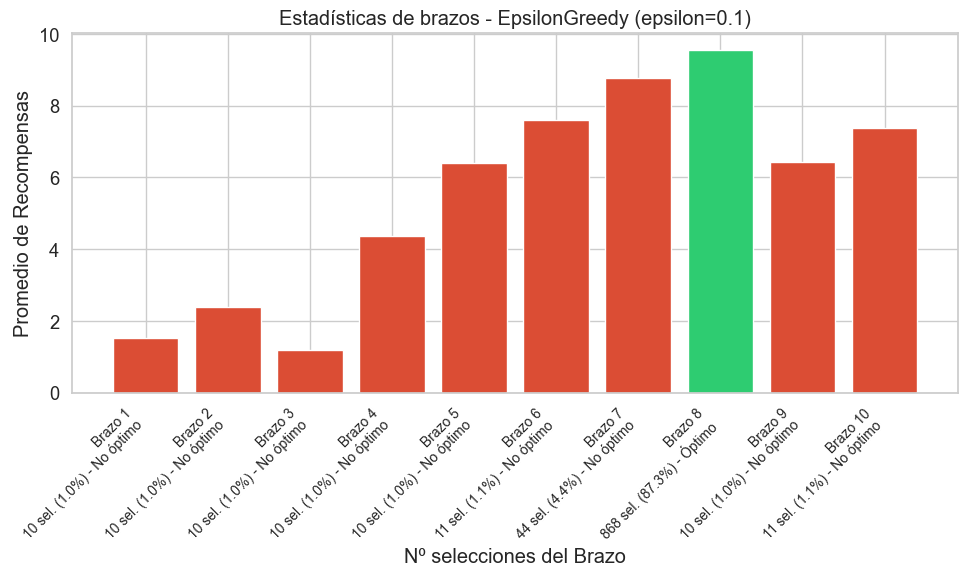

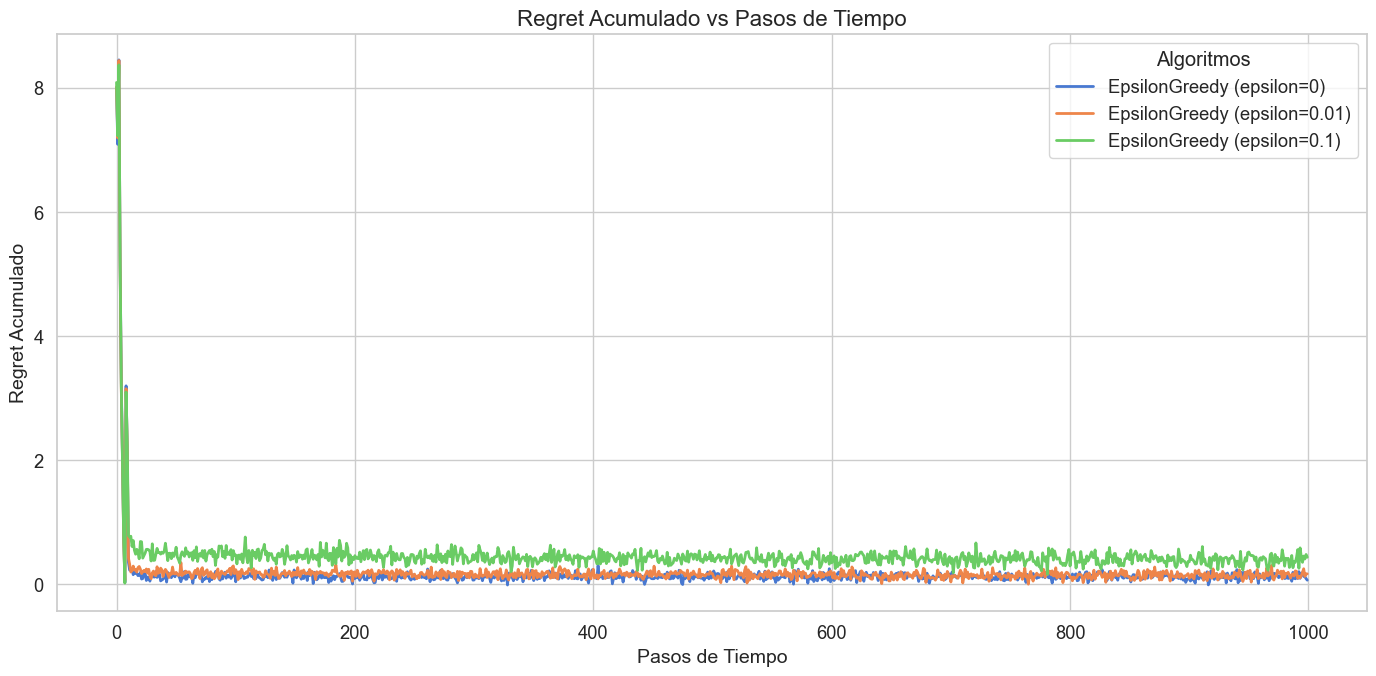

In [78]:
# Graficar los resultados
plot_average_rewards(steps, rewards, algorithms)
plot_optimal_selections(steps, optimal_selections, algorithms)
plot_arm_statistics(arm_stats, algorithms)
plot_regret(steps, regrets, algorithms)

### Análisis

## ``Experimento distribución Bernoulli``

In [79]:
# Creación del bandit
bandit = Bandit(arms=ArmBernoulli.generate_arms(k)) # Generar un bandido con k brazos de distribución de Bernoulli
print(bandit)

optimal_arm = bandit.optimal_arm
print(f"Optimal arm: {optimal_arm + 1} with expected reward={bandit.get_expected_value(optimal_arm)}")

# Definir los algoritmos a comparar. En este caso son 3 algoritmos epsilon-greedy con diferentes valores de epsilon.
algorithms = [EpsilonGreedy(k=k, epsilon=0), EpsilonGreedy(k=k, epsilon=0.01), EpsilonGreedy(k=k, epsilon=0.1)]

# Ejecutar el experimento y obtener las recompensas promedio, porcentaje de selecciones óptimas y estadísticas de brazos
rewards, optimal_selections, arm_stats, regrets = run_experiment(bandit, algorithms, steps, runs)

Bandit with 10 arms: ArmBernoulli(p=0.7), ArmBernoulli(p=0.35), ArmBernoulli(p=0.79), ArmBernoulli(p=0.34), ArmBernoulli(p=0.42), ArmBernoulli(p=0.08), ArmBernoulli(p=0.68), ArmBernoulli(p=0.69), ArmBernoulli(p=0.65), ArmBernoulli(p=0.73)
Optimal arm: 3 with expected reward=0.79


### Visualización

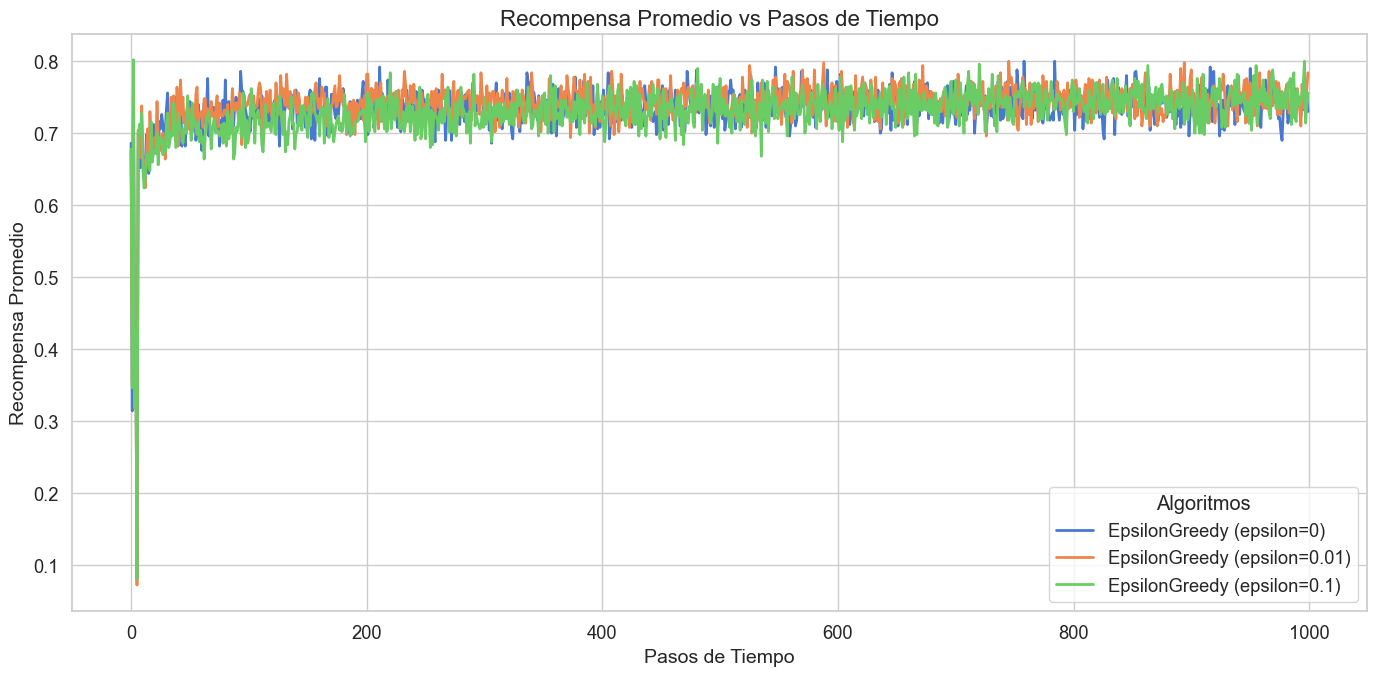

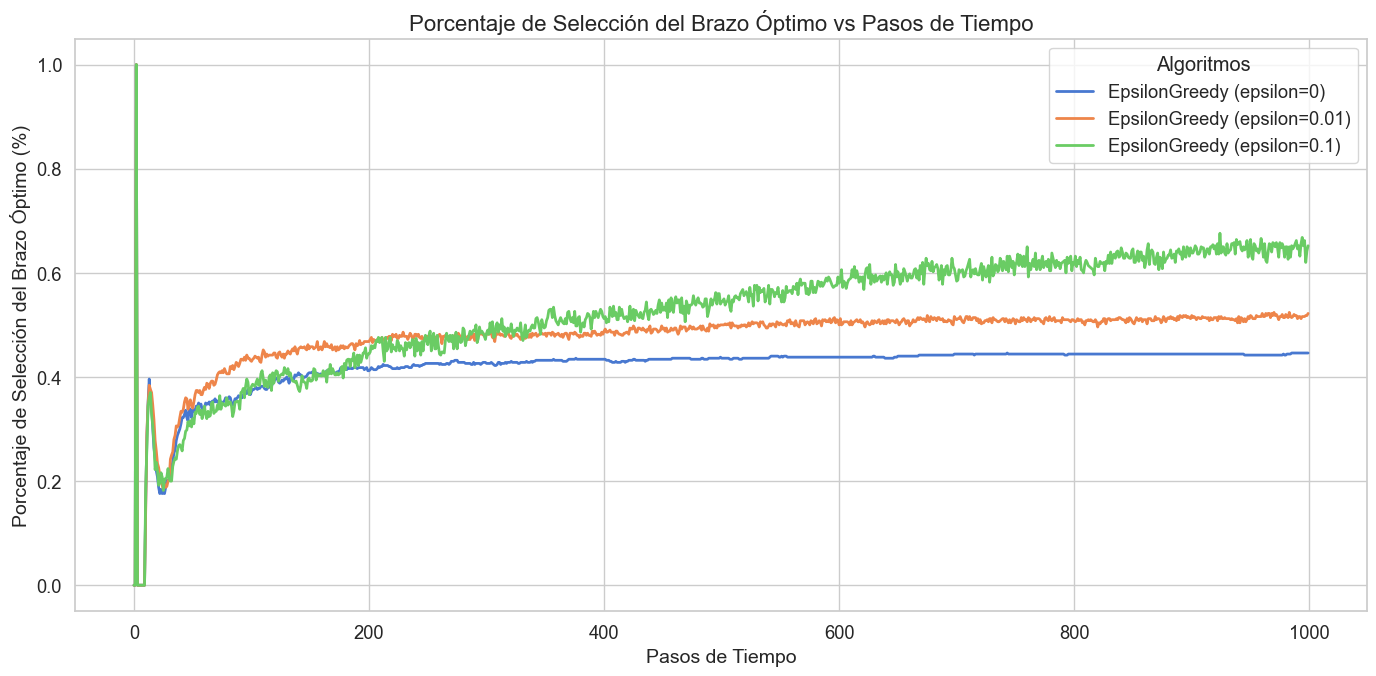


Estadísticas de brazos - EpsilonGreedy (epsilon=0)
Brazo 1: Recompensa Promedio = 0.4257, Selecciones = 118
Brazo 2: Recompensa Promedio = 0.1694, Selecciones = 1
Brazo 3: Recompensa Promedio = 0.5467, Selecciones = 418 (ÓPTIMO)
Brazo 4: Recompensa Promedio = 0.1981, Selecciones = 3
Brazo 5: Recompensa Promedio = 0.2321, Selecciones = 2
Brazo 6: Recompensa Promedio = 0.0413, Selecciones = 1
Brazo 7: Recompensa Promedio = 0.4313, Selecciones = 92
Brazo 8: Recompensa Promedio = 0.4255, Selecciones = 105
Brazo 9: Recompensa Promedio = 0.3936, Selecciones = 63
Brazo 10: Recompensa Promedio = 0.4501, Selecciones = 193


c:\Users\lolac\Documents\GitHub\SalasOrtegaConde1\plotting\plotting.py:136: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(x_labels, rotation=45, ha="right", fontsize=10)


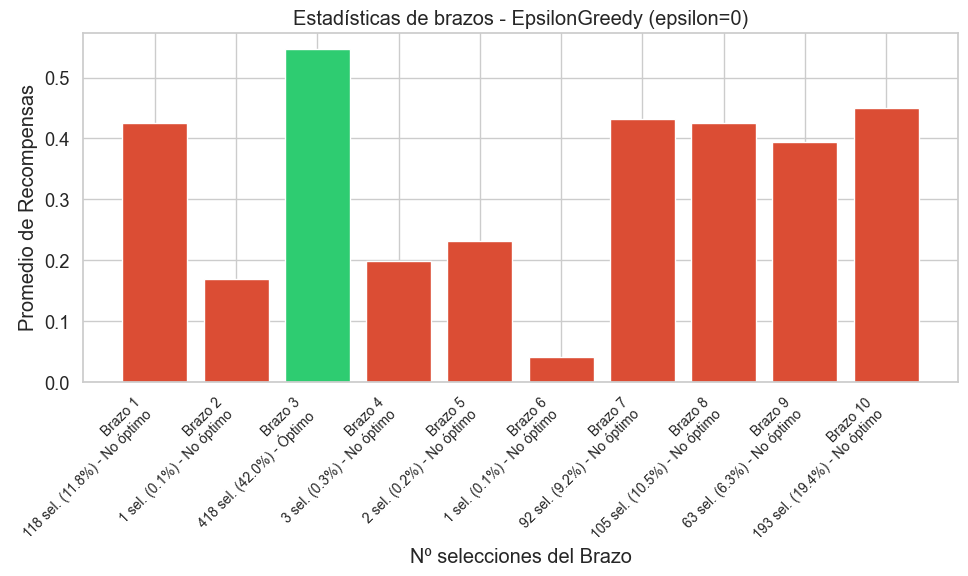


Estadísticas de brazos - EpsilonGreedy (epsilon=0.01)
Brazo 1: Recompensa Promedio = 0.4985, Selecciones = 117
Brazo 2: Recompensa Promedio = 0.2546, Selecciones = 2
Brazo 3: Recompensa Promedio = 0.6388, Selecciones = 476 (ÓPTIMO)
Brazo 4: Recompensa Promedio = 0.2403, Selecciones = 2
Brazo 5: Recompensa Promedio = 0.2767, Selecciones = 2
Brazo 6: Recompensa Promedio = 0.0572, Selecciones = 2
Brazo 7: Recompensa Promedio = 0.5070, Selecciones = 76
Brazo 8: Recompensa Promedio = 0.5119, Selecciones = 96
Brazo 9: Recompensa Promedio = 0.4951, Selecciones = 35
Brazo 10: Recompensa Promedio = 0.5535, Selecciones = 185


c:\Users\lolac\Documents\GitHub\SalasOrtegaConde1\plotting\plotting.py:136: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(x_labels, rotation=45, ha="right", fontsize=10)


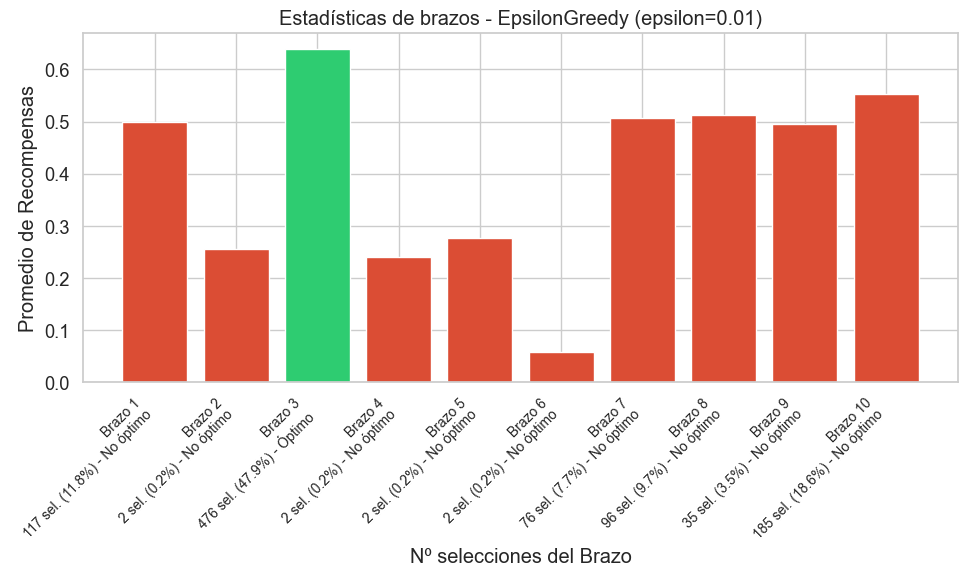

c:\Users\lolac\Documents\GitHub\SalasOrtegaConde1\plotting\plotting.py:136: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(x_labels, rotation=45, ha="right", fontsize=10)



Estadísticas de brazos - EpsilonGreedy (epsilon=0.1)
Brazo 1: Recompensa Promedio = 0.6446, Selecciones = 93
Brazo 2: Recompensa Promedio = 0.3278, Selecciones = 11
Brazo 3: Recompensa Promedio = 0.7500, Selecciones = 523 (ÓPTIMO)
Brazo 4: Recompensa Promedio = 0.3335, Selecciones = 11
Brazo 5: Recompensa Promedio = 0.4109, Selecciones = 12
Brazo 6: Recompensa Promedio = 0.0744, Selecciones = 10
Brazo 7: Recompensa Promedio = 0.6370, Selecciones = 61
Brazo 8: Recompensa Promedio = 0.6415, Selecciones = 74
Brazo 9: Recompensa Promedio = 0.6168, Selecciones = 33
Brazo 10: Recompensa Promedio = 0.6746, Selecciones = 167


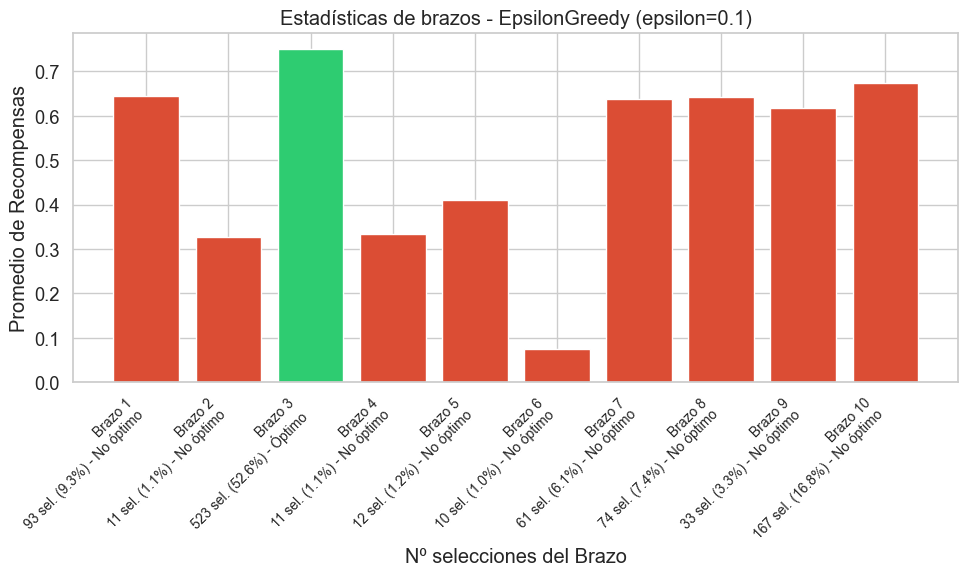

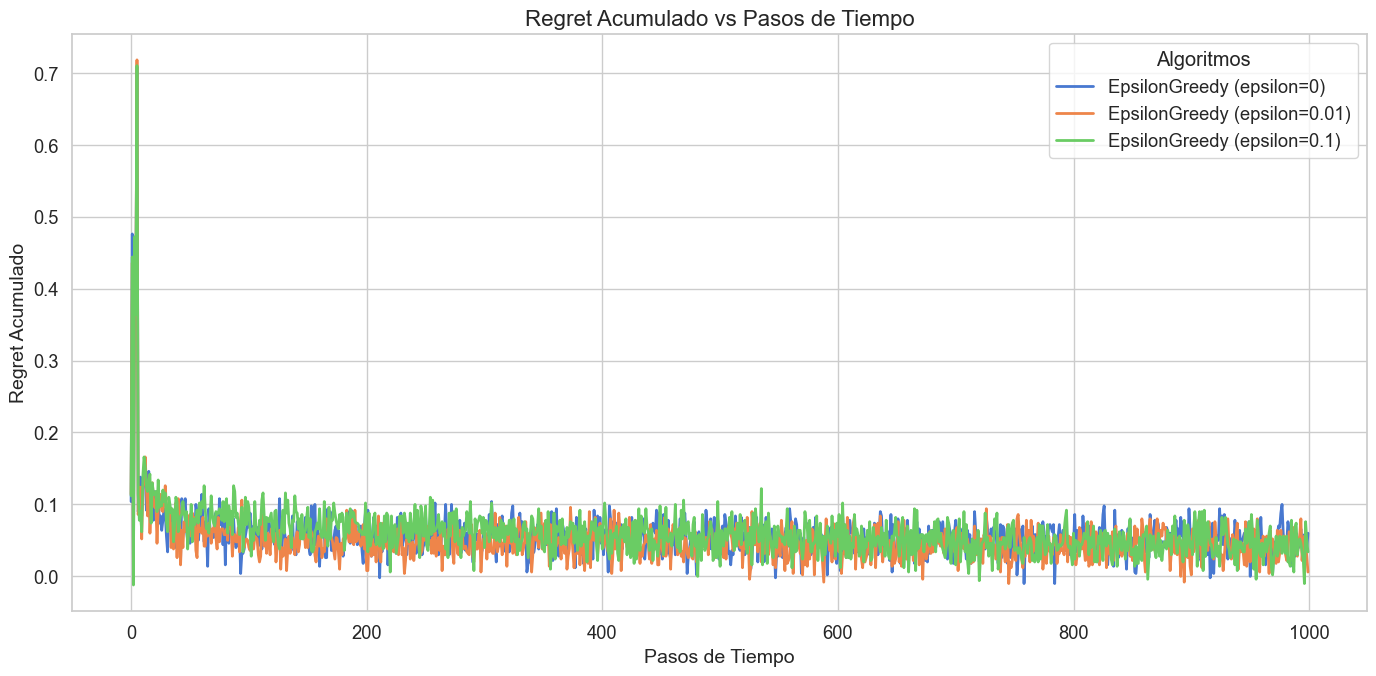

In [80]:
# Graficar los resultados
plot_average_rewards(steps, rewards, algorithms)
plot_optimal_selections(steps, optimal_selections, algorithms)
plot_arm_statistics(arm_stats, algorithms)
plot_regret(steps, regrets, algorithms)

### Análisis

## ``Experimento distribución Binomial``

In [81]:
# Creación del bandit
bandit = Bandit(arms=ArmBinomial.generate_arms(k)) # Generar un bandido con k brazos de distribución binomial
print(bandit)

optimal_arm = bandit.optimal_arm
print(f"Optimal arm: {optimal_arm + 1} with expected reward={bandit.get_expected_value(optimal_arm)}")

# Definir los algoritmos a comparar. En este caso son 3 algoritmos epsilon-greedy con diferentes valores de epsilon.
algorithms = [EpsilonGreedy(k=k, epsilon=0), EpsilonGreedy(k=k, epsilon=0.01), EpsilonGreedy(k=k, epsilon=0.1)]

# Ejecutar el experimento y obtener las recompensas promedio, porcentaje de selecciones óptimas y estadísticas de brazos
rewards, optimal_selections, arm_stats, regrets = run_experiment(bandit, algorithms, steps, runs)

Bandit with 10 arms: ArmBinomial(n=10, p=0.37), ArmBinomial(n=10, p=0.78), ArmBinomial(n=10, p=0.58), ArmBinomial(n=10, p=0.99), ArmBinomial(n=10, p=0.52), ArmBinomial(n=10, p=0.49), ArmBinomial(n=10, p=0.39), ArmBinomial(n=10, p=0.06), ArmBinomial(n=10, p=0.12), ArmBinomial(n=10, p=0.02)
Optimal arm: 4 with expected reward=9.9


### Visualización

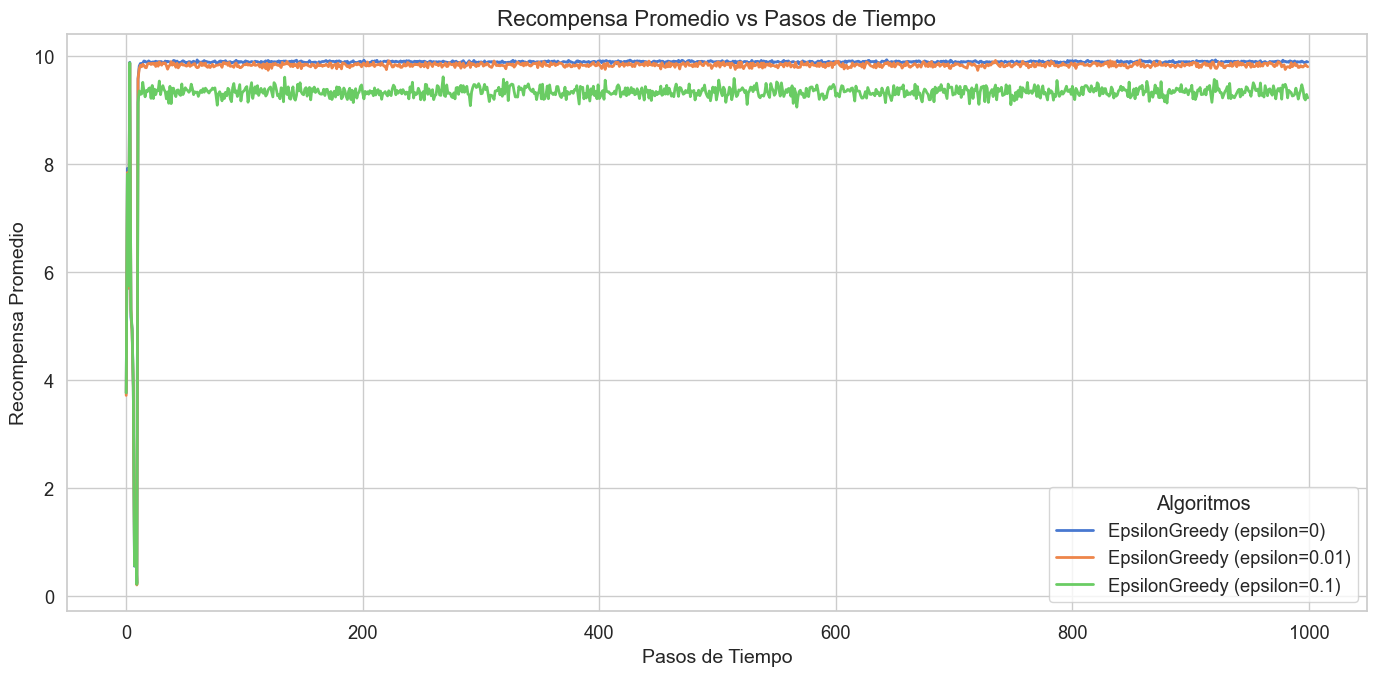

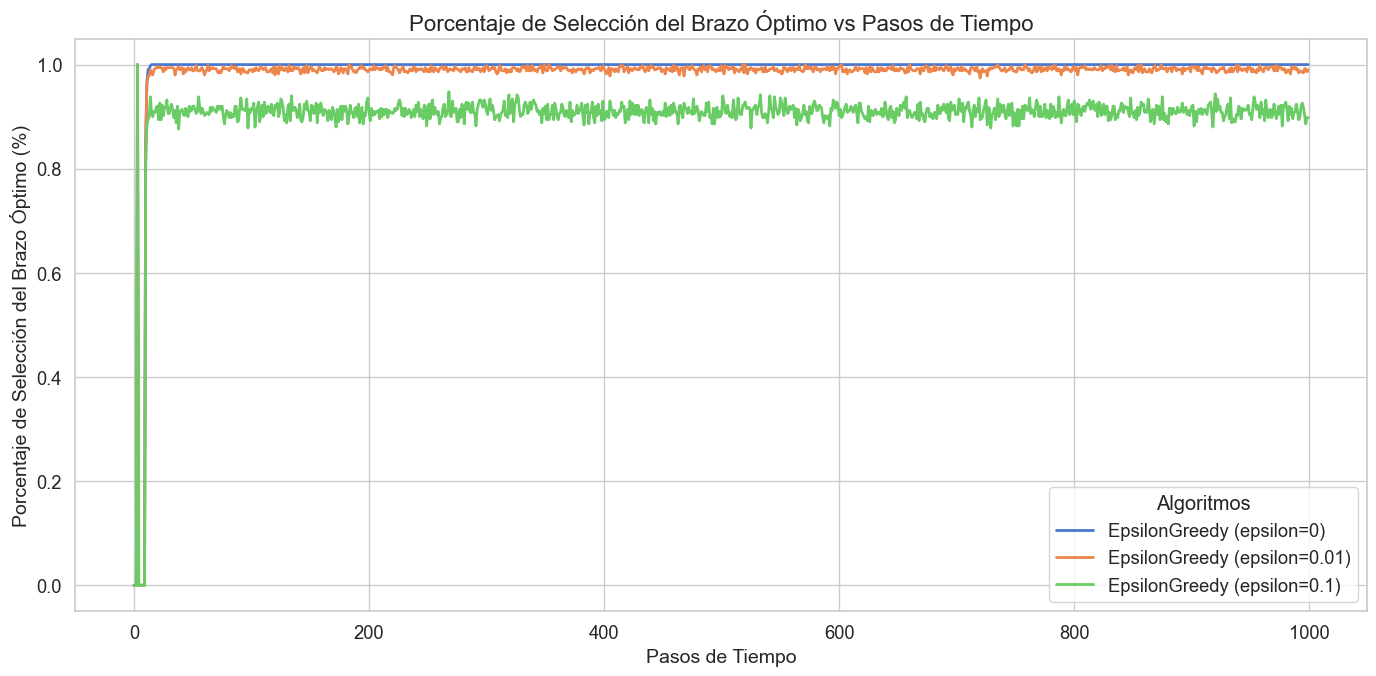


Estadísticas de brazos - EpsilonGreedy (epsilon=0)
Brazo 1: Recompensa Promedio = 3.7600, Selecciones = 1
Brazo 2: Recompensa Promedio = 7.7633, Selecciones = 1
Brazo 3: Recompensa Promedio = 5.6977, Selecciones = 1
Brazo 4: Recompensa Promedio = 9.8997, Selecciones = 990 (ÓPTIMO)
Brazo 5: Recompensa Promedio = 5.1650, Selecciones = 1
Brazo 6: Recompensa Promedio = 4.9480, Selecciones = 1
Brazo 7: Recompensa Promedio = 3.8680, Selecciones = 1
Brazo 8: Recompensa Promedio = 0.5520, Selecciones = 1
Brazo 9: Recompensa Promedio = 1.1180, Selecciones = 1
Brazo 10: Recompensa Promedio = 0.2380, Selecciones = 1


c:\Users\lolac\Documents\GitHub\SalasOrtegaConde1\plotting\plotting.py:136: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(x_labels, rotation=45, ha="right", fontsize=10)


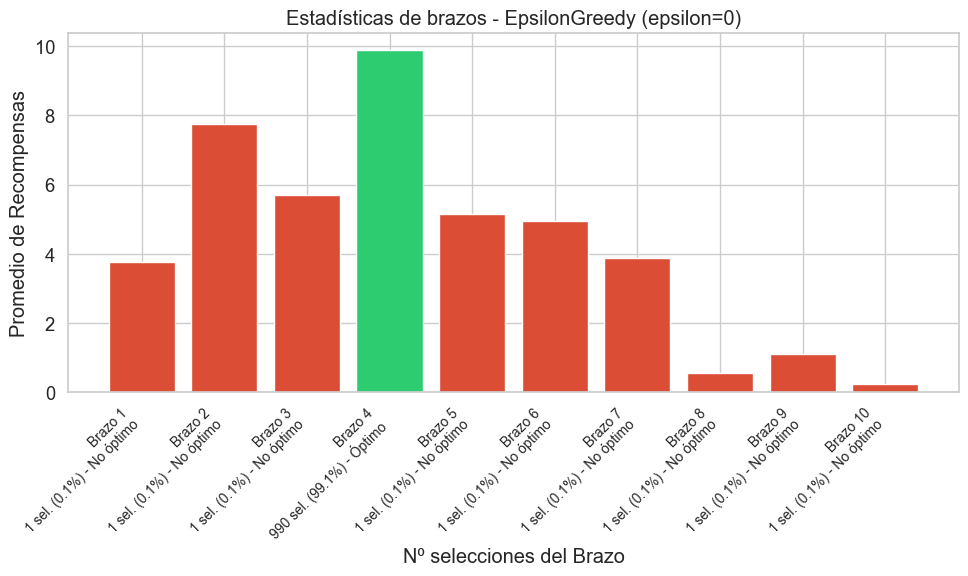


Estadísticas de brazos - EpsilonGreedy (epsilon=0.01)
Brazo 1: Recompensa Promedio = 3.7543, Selecciones = 2
Brazo 2: Recompensa Promedio = 7.8011, Selecciones = 2
Brazo 3: Recompensa Promedio = 5.6777, Selecciones = 1
Brazo 4: Recompensa Promedio = 9.8993, Selecciones = 981 (ÓPTIMO)
Brazo 5: Recompensa Promedio = 5.2808, Selecciones = 1
Brazo 6: Recompensa Promedio = 4.9103, Selecciones = 1
Brazo 7: Recompensa Promedio = 3.8908, Selecciones = 2
Brazo 8: Recompensa Promedio = 0.6412, Selecciones = 2
Brazo 9: Recompensa Promedio = 1.1531, Selecciones = 1
Brazo 10: Recompensa Promedio = 0.2094, Selecciones = 2


c:\Users\lolac\Documents\GitHub\SalasOrtegaConde1\plotting\plotting.py:136: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(x_labels, rotation=45, ha="right", fontsize=10)


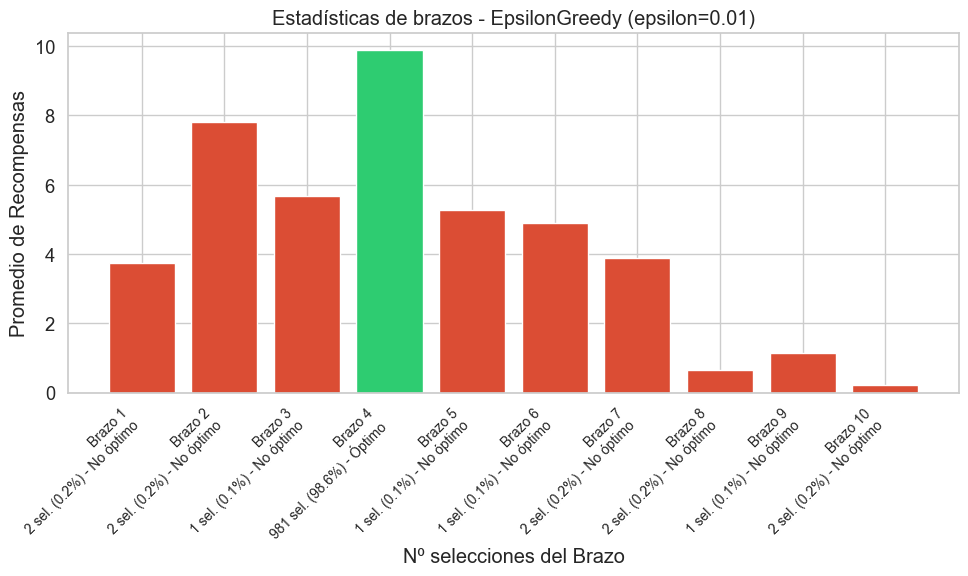


Estadísticas de brazos - EpsilonGreedy (epsilon=0.1)
Brazo 1: Recompensa Promedio = 3.7170, Selecciones = 10
Brazo 2: Recompensa Promedio = 7.8139, Selecciones = 11
Brazo 3: Recompensa Promedio = 5.7436, Selecciones = 10
Brazo 4: Recompensa Promedio = 9.9002, Selecciones = 902 (ÓPTIMO)
Brazo 5: Recompensa Promedio = 5.1900, Selecciones = 10
Brazo 6: Recompensa Promedio = 4.8884, Selecciones = 10
Brazo 7: Recompensa Promedio = 3.8928, Selecciones = 10
Brazo 8: Recompensa Promedio = 0.6039, Selecciones = 10
Brazo 9: Recompensa Promedio = 1.1838, Selecciones = 11
Brazo 10: Recompensa Promedio = 0.2015, Selecciones = 10


c:\Users\lolac\Documents\GitHub\SalasOrtegaConde1\plotting\plotting.py:136: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(x_labels, rotation=45, ha="right", fontsize=10)


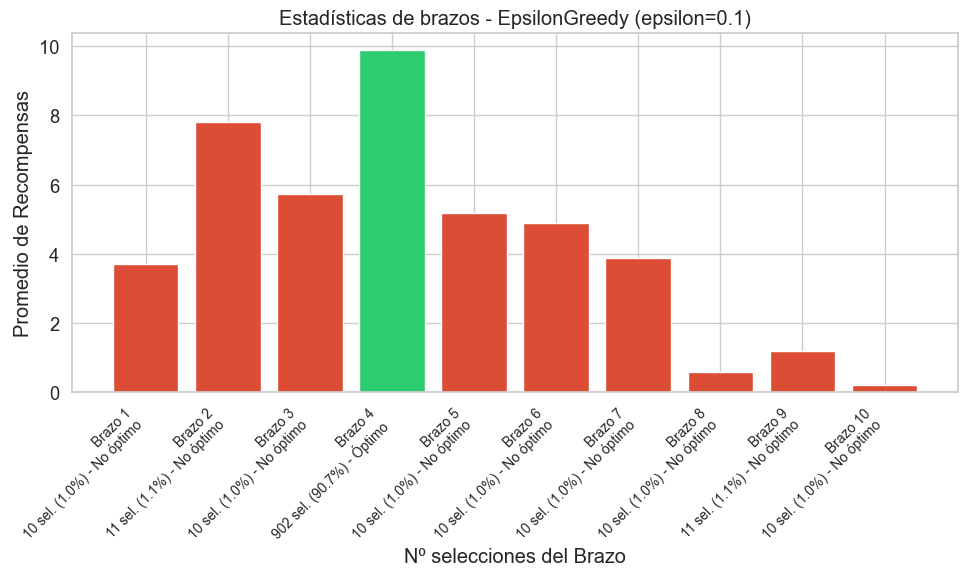

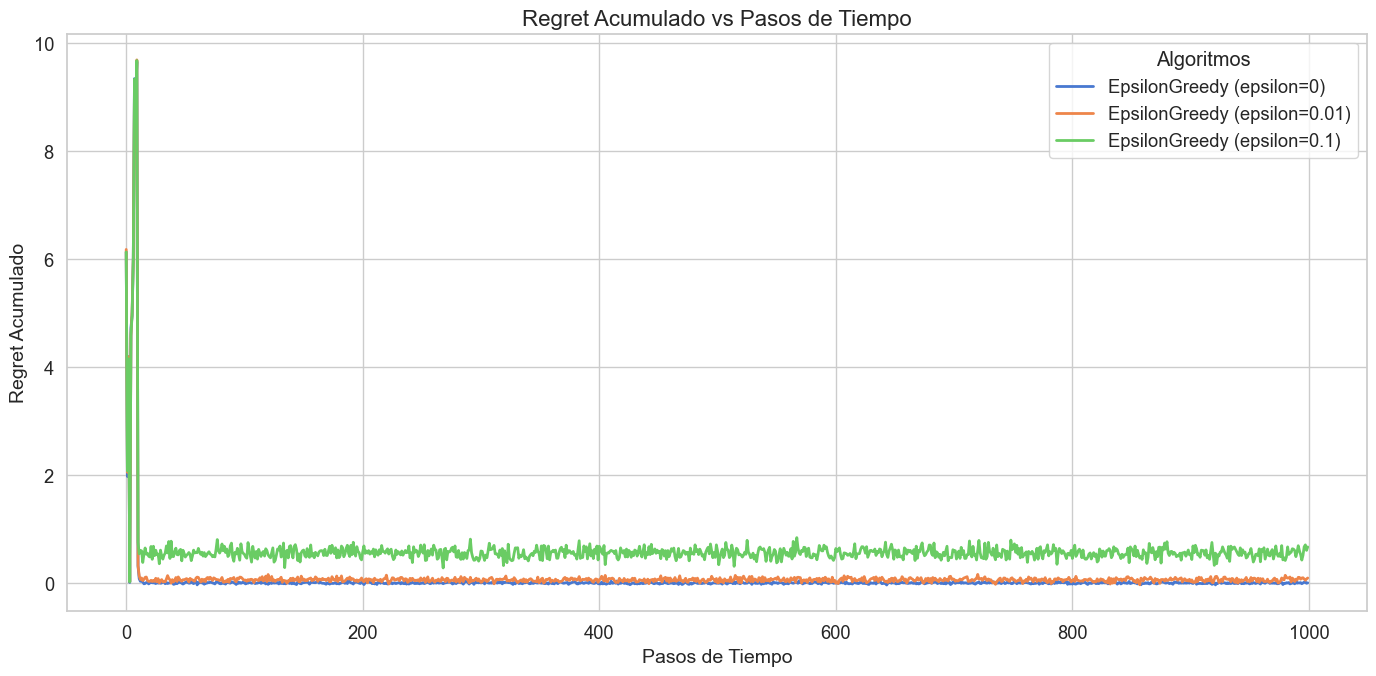

In [82]:
# Graficar los resultados
plot_average_rewards(steps, rewards, algorithms)
plot_optimal_selections(steps, optimal_selections, algorithms)
plot_arm_statistics(arm_stats, algorithms)
plot_regret(steps, regrets, algorithms)

### Análisis